#Task 6: Bidirectional Long Short-Term Memory (BiLSTM) Cell Mechanics from Scratch
#Objective:
 Learn sequence transduction architectures and dynamic temporal tracking by
implementing gated recurrent equations and memory routing layouts from scratch.
#Required Tech Stack:
 PyTorch (Tensor operations only, no nn.RNN or nn.LSTM), NumPy.
#Task Description:
Students will design and execute a bidirectional LSTM layer. They must
write individual loop-based step updates calculating Input ( ), Forget ( ), Output ( ),
and Cell State Candidate ( ) activations, stitch backward and forward sequence steps,
and handle dynamic sequence-padded packs.

Import Libraries

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

Create Sample Data

In [2]:
batch_size = 4
seq_len = 6
input_size = 5
hidden_size = 8

X = torch.randn(batch_size, seq_len, input_size)

print("Input Shape:", X.shape)

Input Shape: torch.Size([4, 6, 5])


Initialize Parameters

In [3]:
def init_weights(input_size, hidden_size):

    return {
        "Wf": torch.randn(input_size + hidden_size, hidden_size) * 0.1,
        "Wi": torch.randn(input_size + hidden_size, hidden_size) * 0.1,
        "Wo": torch.randn(input_size + hidden_size, hidden_size) * 0.1,
        "Wc": torch.randn(input_size + hidden_size, hidden_size) * 0.1,

        "bf": torch.zeros(hidden_size),
        "bi": torch.zeros(hidden_size),
        "bo": torch.zeros(hidden_size),
        "bc": torch.zeros(hidden_size)
    }

params_forward = init_weights(input_size, hidden_size)
params_backward = init_weights(input_size, hidden_size)

Activation Functions

In [4]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def tanh(x):
    return torch.tanh(x)

Single LSTM Cell

In [5]:
def lstm_cell(x, h_prev, c_prev, params):

    combined = torch.cat((x, h_prev), dim=1)

    f = sigmoid(combined @ params["Wf"] + params["bf"])
    i = sigmoid(combined @ params["Wi"] + params["bi"])
    o = sigmoid(combined @ params["Wo"] + params["bo"])
    g = tanh(combined @ params["Wc"] + params["bc"])

    c = f * c_prev + i * g
    h = o * tanh(c)

    return h, c

Forward LSTM

In [6]:
def forward_lstm(X, params):

    batch_size = X.shape[0]

    h = torch.zeros(batch_size, hidden_size)
    c = torch.zeros(batch_size, hidden_size)

    outputs = []

    for t in range(X.shape[1]):

        h, c = lstm_cell(X[:, t, :], h, c, params)
        outputs.append(h)

    return torch.stack(outputs, dim=1)

Backward LSTM

In [7]:
def backward_lstm(X, params):

    batch_size = X.shape[0]

    h = torch.zeros(batch_size, hidden_size)
    c = torch.zeros(batch_size, hidden_size)

    outputs = []

    for t in reversed(range(X.shape[1])):

        h, c = lstm_cell(X[:, t, :], h, c, params)
        outputs.insert(0, h)

    return torch.stack(outputs, dim=1)

Bidirectional LSTM

In [8]:
forward_output = forward_lstm(X, params_forward)
backward_output = backward_lstm(X, params_backward)

bilstm_output = torch.cat(
    (forward_output, backward_output),
    dim=2
)

print("Forward Output :", forward_output.shape)
print("Backward Output:", backward_output.shape)
print("BiLSTM Output  :", bilstm_output.shape)

Forward Output : torch.Size([4, 6, 8])
Backward Output: torch.Size([4, 6, 8])
BiLSTM Output  : torch.Size([4, 6, 16])


Display Hidden States

In [9]:
print("Forward Hidden State (First Sample):")
print(forward_output[0])

print("\nBackward Hidden State (First Sample):")
print(backward_output[0])

Forward Hidden State (First Sample):
tensor([[-0.0064, -0.1052,  0.0412,  0.0501,  0.0771, -0.0521, -0.0131,  0.1129],
        [ 0.0890, -0.0570,  0.0685,  0.0564,  0.0483, -0.1033,  0.0310, -0.0016],
        [ 0.0693,  0.0784,  0.0075, -0.0120,  0.0216, -0.0218,  0.0979, -0.0027],
        [ 0.0275, -0.0657,  0.0632,  0.0395,  0.0351, -0.0367,  0.0251,  0.0648],
        [ 0.0159, -0.1140,  0.0491,  0.0548,  0.0111, -0.0785, -0.1245, -0.0821],
        [-0.0020, -0.1308,  0.0375,  0.0474,  0.0479, -0.0461, -0.1060,  0.0024]])

Backward Hidden State (First Sample):
tensor([[ 0.1293, -0.0682, -0.0292, -0.1150, -0.1252, -0.1308, -0.0323, -0.0476],
        [ 0.0277,  0.0146, -0.0773,  0.0914,  0.0063, -0.0189,  0.1071,  0.0457],
        [ 0.0139, -0.0071, -0.0675, -0.0039, -0.0196, -0.0098, -0.0165,  0.0387],
        [ 0.0290, -0.0029,  0.1122, -0.1243, -0.0724,  0.0082,  0.0240, -0.0854],
        [-0.0312,  0.0103,  0.0884, -0.0759,  0.0117,  0.0387,  0.0650, -0.0392],
        [ 0.0322, -0.

Visualization

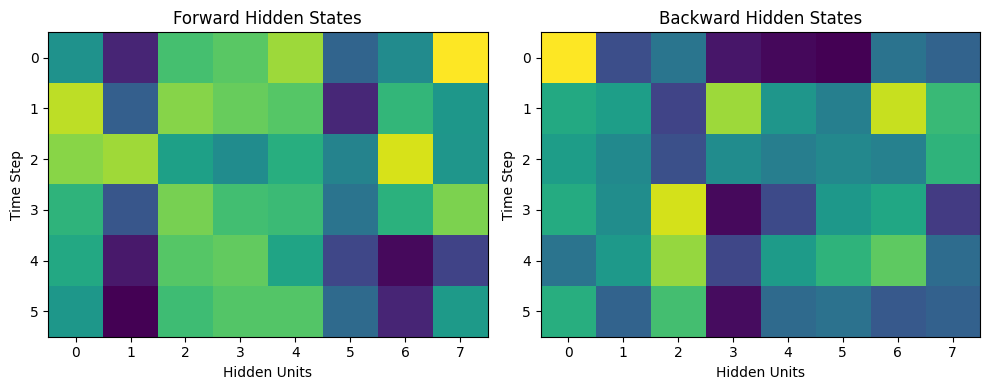

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(forward_output[0].numpy(), aspect='auto', cmap='viridis')
plt.title("Forward Hidden States")
plt.xlabel("Hidden Units")
plt.ylabel("Time Step")

plt.subplot(1, 2, 2)
plt.imshow(backward_output[0].numpy(), aspect='auto', cmap='viridis')
plt.title("Backward Hidden States")
plt.xlabel("Hidden Units")
plt.ylabel("Time Step")

plt.tight_layout()
plt.show()